# Lista 04 de Visão Computacional

Beatriz Rodrigues Cavalcante - 22210505

Hugo Coêlho da Silva - 22111533

Link da lista: https://drive.google.com/file/d/1RLlDFoV_hk_BUscJiveLQ8e_TXUyxZl4/view


## Importações e Funções Auxiliares


In [12]:
import os
from pathlib import Path

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix


def show_images(
    *images: np.ndarray,
    titles: list[str] | None = None,
    columns: int = 2,
    scale: int = 5,
) -> None:
    num_images = len(images)

    if titles is None:
        titles = [f"Image {i + 1}" for i in range(num_images)]

    rows = (num_images + columns - 1) // columns

    fig, axes = plt.subplots(rows, columns, figsize=(scale * columns, scale * rows))
    axes = np.array(axes).reshape(rows, columns)

    for ax, img, title in zip(axes.flat, images, titles):
        if img is None:
            ax.axis("off")
            continue
        img_disp = img
        ax.imshow(img_disp, cmap="gray" if img_disp.ndim == 2 else None)
        ax.set_title(title)

    for i in range(num_images, rows * columns):
        fig.delaxes(axes.flat[i])

    plt.tight_layout()

# Questão 1 - Item A)

Nesta questão, treinamos um classificador SVM para distinguir entre as classes "gato" vs "cachorro" e "chihuahua" vs "muffin" usando descritores HOG.

Para isso, lemos o dataset de imagens, e o convertemos para escala de cinza e redimensionamos para um tamanho fixo (nesse caso, foi escolhifo o 128x128). Em seguida, extraímos os descritores HOG de cada imagem, usando os parâmetros: `window size: (64,64)`, `block size: (32, 32)`, `block stride: (16, 16)`, `cell size: (16, 16)`, `number of bins: 9`; aí armazenamos essa imagem em um dataframe, junto do label e do img_path. Depois, dividimos o dataset em treino e teste, e treinamos um classificador SVM, com um kernel linear, então é feita a predição e a avaliação do modelo, usando a matriz de confusão e o relatório de classificação.





In [27]:
# https://umatechnology.org/how-to-train-an-object-detection-engine-with-hog-in-opencv/
# https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification

IMG_SIZE = 128
N_EX = 5

def extract_features(hog: cv.HOGDescriptor, base_dir: Path):
    data = []
    for label, category in enumerate(base_dir.iterdir()):
        for file in os.listdir(category):
            img_path = os.path.join(category, file)
            img = cv.imread(img_path, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(
                {
                    "features": hog.compute(img).flatten(),
                    "label": label,
                    "path": img_path,
                }
            )
    return pd.DataFrame(data)


def train_svm(features: pd.DataFrame):
    df_train, df_test = train_test_split(
        features, test_size=0.30, stratify=features["label"], random_state=42
    )

    X_train = np.stack(df_train["features"].to_numpy())
    y_train = df_train["label"].to_numpy()
    X_test = np.stack(df_test["features"].to_numpy())

    svm_model = SVC(kernel="linear")
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    return y_pred, df_test


def generate_cm(y_test, y_pred, labels):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")
    plt.show()


def show_examples(df: pd.DataFrame, labels: list, title: str):
    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(df.iterrows()):
        img = cv.imread(row["path"])
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        plt.subplot(1, len(df), i + 1)
        plt.title(f"Pred: {labels[row['pred']]}")
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()


def show_correct_n_wrongs(df_test, y_pred, labels):
    df_test = df_test.copy()
    df_test["pred"] = y_pred

    df_correct = df_test[df_test["label"] == df_test["pred"]]
    df_correct = df_correct.sample(min(N_EX, len(df_correct)), random_state=10)
    df_wrong = df_test[df_test["label"] != df_test["pred"]]
    df_wrong = df_wrong.sample(min(N_EX, len(df_wrong)), random_state=42)

    show_examples(df_correct, labels, "Exemplos classificados corretamente")
    show_examples(df_wrong, labels, "Exemplos classificados incorretamente")


              precision    recall  f1-score   support

           0       0.90      0.91      0.90       150
           1       0.91      0.90      0.90       150

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



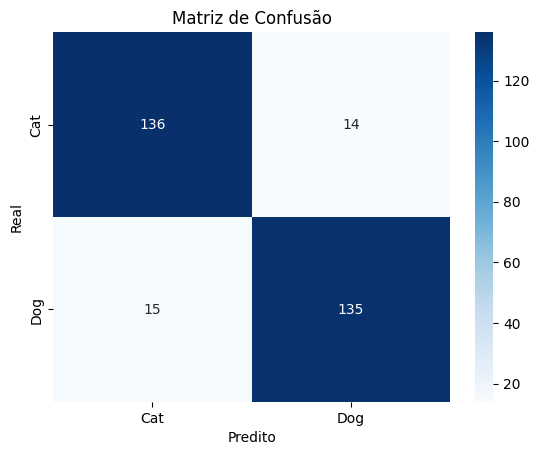

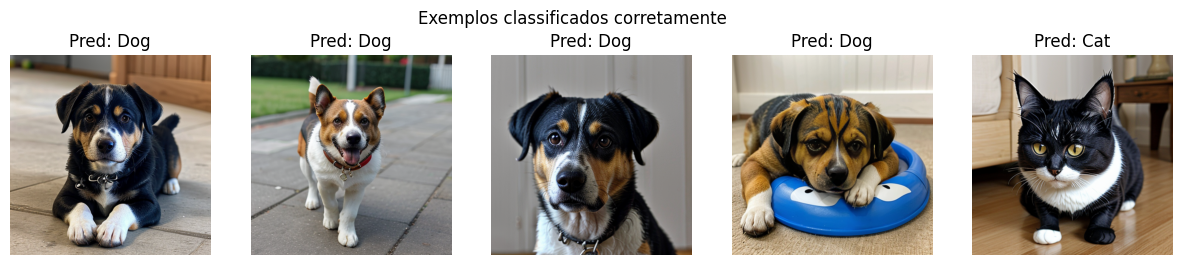

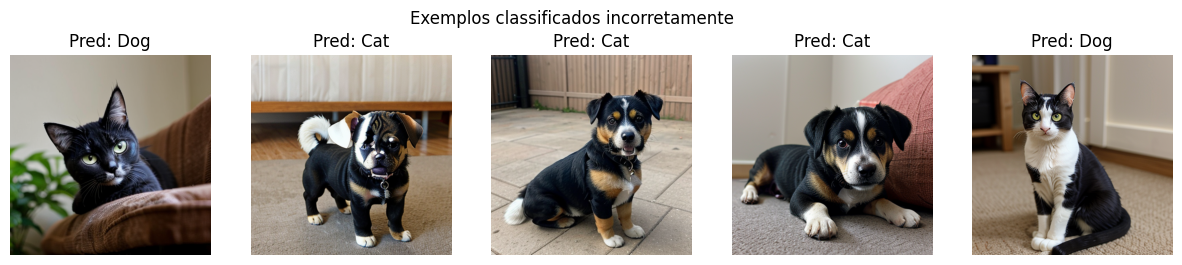

In [28]:
base_dir = "dataset1"
categories = ["Cat", "Dog"]
hog = cv.HOGDescriptor(
    _winSize=(IMG_SIZE, IMG_SIZE),
    _blockSize=(32, 32),
    _blockStride=(16, 16),
    _cellSize=(16, 16),
    _nbins=9,
)

feats = extract_features(hog, Path(base_dir))
y_pred, df_test = train_svm(feats)


result = classification_report(df_test["label"], y_pred)
print(result)
generate_cm(df_test["label"], y_pred, categories)

show_correct_n_wrongs(df_test, y_pred, categories)


              precision    recall  f1-score   support

           0       0.76      0.78      0.77       816
           1       0.81      0.79      0.80       960

    accuracy                           0.78      1776
   macro avg       0.78      0.78      0.78      1776
weighted avg       0.78      0.78      0.78      1776



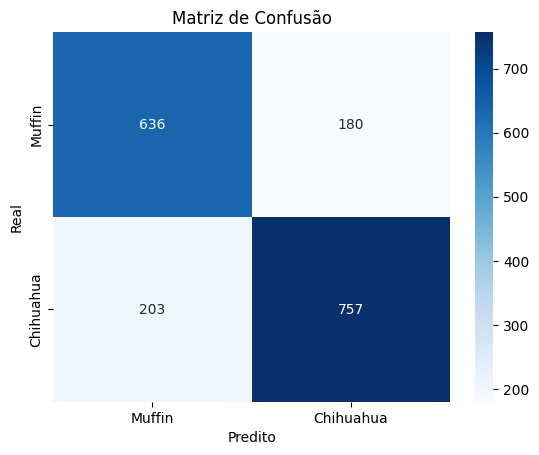

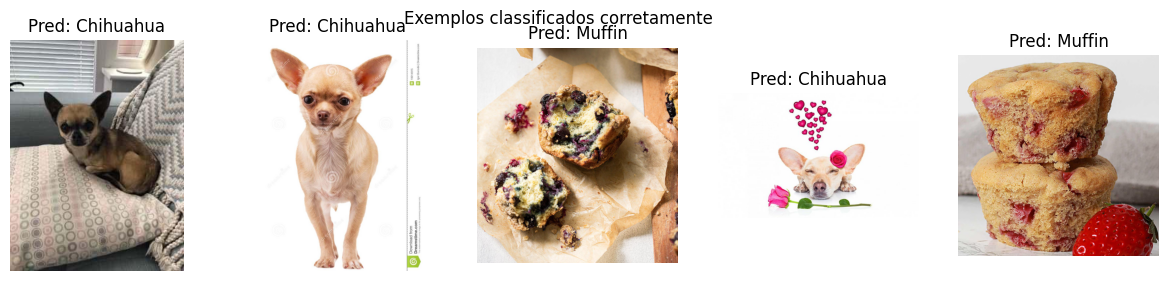

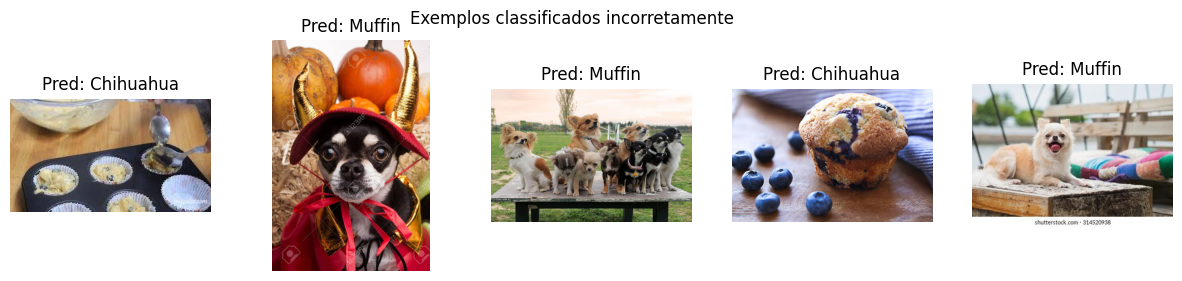

In [29]:
base_dir = "dataset2"
categories = ["Muffin", "Chihuahua"]
hog = cv.HOGDescriptor(
    _winSize=(IMG_SIZE, IMG_SIZE),
    _blockSize=(32, 32),
    _blockStride=(16, 16),
    _cellSize=(16, 16),
    _nbins=9,
)

feats = extract_features(hog, Path(base_dir))
y_pred, df_test = train_svm(feats)


result = classification_report(df_test["label"], y_pred)
print(result)
generate_cm(df_test["label"], y_pred, categories)

show_correct_n_wrongs(df_test, y_pred, categories)


## Questão 1 - Item B)
Nesta questão, treinamos uma CNN usando a abordagem de transferência, usando os modelos pré-treinados VGG16, ResNet50 e MobileNetV2, para distinguir entre as classes "gato" vs "cachorro" e "chihuahua" vs "muffin".